In [141]:
# ============================================================
# BTCUSD COMPLEX WXY BACKTEST — VERSION 1
# ============================================================
# Strategy:   Complex WXY Corrective Structure Short
#             Smaller y = smaller w equality trigger
#             RSI momentum confirmation
#             ATR based position sizing
#             Email alerts at key levels
# Timeframe:  4 Hour
# Data:       BTC-USD via yfinance
# Capital:    $1,000,000 simulated
# Risk:       $100,000 per trade (10% of capital)
# By:         Munyaradzi Nyika | Wave and Code
# Research:   waveandcode.substack.com
# Code:       github.com/mnyika-quant
# Signals:    t.me/waveandcodesignals
# ============================================================

!pip install yfinance pandas numpy matplotlib --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')


All libraries imported successfully


In [142]:
# ============================================================
# EMAIL ALERT SYSTEM
#
# Sends automated emails to munyacountry@gmail.com
# when price reaches key levels
#
# SETUP REQUIRED:
# 1. Go to myaccount.google.com
# 2. Click Security
# 3. Click 2 Step Verification — enable if not already on
# 4. Search for App Passwords
# 5. Create new app password for Mail
# 6. Copy the 16 character password
# 7. Paste it below as EMAIL_PASSWORD
# ============================================================

EMAIL_ADDRESS  = 'munyacountry@gmail.com'
EMAIL_PASSWORD = 'oqkj uyjp vrja epjm'
  # Replace with Gmail app password

def send_alert(subject, message):
    """
    Send email alert to munyacountry@gmail.com
    Called automatically when price hits key levels
    """
    try:
        msg = MIMEMultipart()
        msg['From']    = EMAIL_ADDRESS
        msg['To']      = EMAIL_ADDRESS
        msg['Subject'] = f'BTCUSD ALERT — {subject}'

        body = f"""
Wave and Code — BTCUSD Systematic Trade Alert

{message}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRADE FRAMEWORK REFERENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Primary Entry:        ~74,266
Primary Stop:          76,014
Break Even Trigger:    68,941
Second Trade Trigger:  65,558
Second Trade Stop:     69,595
Re-entry Trigger:      77,305
Re-entry Stop:         80,566
Full Target:           59,930
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Wave and Code | waveandcode.substack.com
        """

        msg.attach(MIMEText(body, 'plain'))
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_PASSWORD)
        server.sendmail(EMAIL_ADDRESS, EMAIL_ADDRESS, msg.as_string())
        server.quit()
        print(f'Alert sent: {subject}')

    except Exception as e:
        print(f'Alert failed: {e}')
        print('Check your Gmail app password in EMAIL_PASSWORD')

print('Email alert system ready')
print(f'Alerts will be sent to: {EMAIL_ADDRESS}')


Email alert system ready
Alerts will be sent to: munyacountry@gmail.com


In [143]:
# ============================================================
# DATA PREPARATION
#
# Source:     BTC-USD via yfinance
# Method:     Download 1H bars then resample to 4H
# Start:      01 January 2026 — captures full wave structure
#             from 59,930 origin through current price action
# ============================================================

# Download 1H data

raw = yf.download(
    'BTC-USD',
    start='2026-01-01',
    end='2026-03-19',
    interval='1h',
    auto_adjust=True,
    progress=False
)


# Flatten multi level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Resample 1H to 4H OHLCV
btc = raw.resample('4h').agg({
    'Open':   'first',
    'High':   'max',
    'Low':    'min',
    'Close':  'last',
    'Volume': 'sum'
}).dropna()

print(f'Shape:          {btc.shape}')
print(f'Date range:     {btc.index[0]} to {btc.index[-1]}')
print(f'Price range:    {btc["Low"].min():.2f} to {btc["High"].max():.2f}')
print(f'Total 4H bars:  {len(btc)}')
print()
print(btc[['Open','High','Low','Close']].tail(5))


Shape:          (455, 5)
Date range:     2026-01-01 00:00:00+00:00 to 2026-03-17 16:00:00+00:00
Price range:    60074.80 to 97860.60
Total 4H bars:  455

Price                              Open          High           Low  \
Datetime                                                              
2026-03-17 00:00:00+00:00  74871.296875  75954.968750  74309.460938   
2026-03-17 04:00:00+00:00  74545.046875  74652.742188  73839.921875   
2026-03-17 08:00:00+00:00  74254.460938  74425.851562  73614.750000   
2026-03-17 12:00:00+00:00  74036.242188  74816.500000  73459.250000   
2026-03-17 16:00:00+00:00  73943.617188  74657.601562  73905.640625   

Price                             Close  
Datetime                                 
2026-03-17 00:00:00+00:00  74423.710938  
2026-03-17 04:00:00+00:00  74257.460938  
2026-03-17 08:00:00+00:00  74057.859375  
2026-03-17 12:00:00+00:00  73949.937500  
2026-03-17 16:00:00+00:00  74635.625000  


In [144]:
# ============================================================
# DATA HEALTH CHECK
#
# Verify all key wave levels fall within dataset range
# All checks must return True before running backtest
# ============================================================

print('=== DATA HEALTH CHECK ===')
print()
print(f'Total 4H bars:    {len(btc)}')
print()
print('Missing values:')
print(btc.isnull().sum())
print()
print('=== KEY LEVEL CHECKS ===')

# Wave structure levels
levels = {
    'Wave W origin      59,930': 59930,
    'Wave W end         72,221': 72221,
    'Wave X end         65,079': 65079,
    'Smaller y=w        74,652': 74652,
    'Primary stop       76,014': 76014,
    'Re-entry trigger   77,305': 77305,
    'Full invalidation  80,566': 80566,
}

for label, level in levels.items():
    in_range = btc['High'].max() >= level >= btc['Low'].min()
    status   = '✅' if in_range else '❌'
    print(f'  {status}  {label}  in range: {in_range}')

print()
print('All ✅ = data is ready. Any ❌ = adjust date range.')




=== DATA HEALTH CHECK ===

Total 4H bars:    455

Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

=== KEY LEVEL CHECKS ===
  ❌  Wave W origin      59,930  in range: False
  ✅  Wave W end         72,221  in range: True
  ✅  Wave X end         65,079  in range: True
  ✅  Smaller y=w        74,652  in range: True
  ✅  Primary stop       76,014  in range: True
  ✅  Re-entry trigger   77,305  in range: True
  ✅  Full invalidation  80,566  in range: True

All ✅ = data is ready. Any ❌ = adjust date range.


In [145]:
# ============================================================
# INDICATORS
#
# RSI — Relative Strength Index
#   Period: 14 bars
#   MA Period: 14 bar rolling mean of RSI
#   Signal: RSI crosses below MA = bearish momentum
#           RSI crosses above MA = bullish momentum
#
# ATR — Average True Range
#   Period: 14 bars
#   Used for: Dynamic position sizing
#   Logic: Risk $100,000 per trade
#          Position size = Risk / (ATR x Contract value)
#          Ensures dollar risk is constant regardless
#          of market volatility
#
# CONTRACT SPECIFICATION — BTCUSD:
#   1 lot = 1 Bitcoin
#   Value per point = $1 per lot
#   At $74,000 per Bitcoin — 1 lot = $74,000 notional
# ============================================================

def calculate_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.where(delta > 0, 0)
    loss     = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi

def calculate_atr(high, low, close, period=14):
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

# Calculate indicators
btc['RSI']    = calculate_rsi(btc['Close'], period=14)
btc['RSI_MA'] = btc['RSI'].rolling(window=14).mean()
btc['ATR']    = calculate_atr(btc['High'], btc['Low'], btc['Close'], period=14)

# Detect RSI crossovers
btc['RSI_cross_below'] = (
    (btc['RSI'] < btc['RSI_MA']) &
    (btc['RSI'].shift(1) >= btc['RSI_MA'].shift(1))
)
btc['RSI_cross_above'] = (
    (btc['RSI'] > btc['RSI_MA']) &
    (btc['RSI'].shift(1) <= btc['RSI_MA'].shift(1))
)

print('Indicators calculated successfully')
print()
print(btc[['Close','RSI','RSI_MA','ATR']].dropna().tail(10))


Indicators calculated successfully

Price                             Close        RSI     RSI_MA          ATR
Datetime                                                                  
2026-03-16 04:00:00+00:00  73494.093750  76.845322  58.326100   723.959821
2026-03-16 08:00:00+00:00  73562.804688  76.537771  59.977289   738.911272
2026-03-16 12:00:00+00:00  73245.906250  78.928320  61.787460   778.115513
2026-03-16 16:00:00+00:00  73962.578125  81.406862  63.156282   834.492188
2026-03-16 20:00:00+00:00  74852.507812  85.839046  65.151160   877.688616
2026-03-17 00:00:00+00:00  74423.710938  79.704102  67.065931   979.228237
2026-03-17 04:00:00+00:00  74257.460938  75.647130  68.180321   996.293527
2026-03-17 08:00:00+00:00  74057.859375  72.766430  69.187683  1005.779018
2026-03-17 12:00:00+00:00  73949.937500  70.928724  69.966104  1073.892857
2026-03-17 16:00:00+00:00  74635.625000  72.245872  71.183363  1092.528460


In [146]:

# ============================================================
# WAVE STRUCTURE — HARDCODED
#
# LARGER WXY CORRECTIVE STRUCTURE:
#
# WAVE W — ABC:
#   A: 59,930 → 71,768  (+11,838 pts)
#   B: 71,768 → 67,323  (-4,445 pts)
#   C: 67,323 → 72,221  (+4,898 pts)
#   W COMPLETE: 59,930 → 72,221
#
# WAVE X — TRIANGLE ABCDE:
#   A: 72,221 → 62,525  (-9,696 pts)
#   B: 62,525 → 70,107  (+7,582 pts)
#   C: 70,107 → 63,037  (-7,070 pts)
#   D: 63,037 → 68,222  (+5,185 pts)
#   E: 68,222 → 65,079  (-3,143 pts)
#   X COMPLETE: 72,221 → 65,079
#
# WAVE Y — WXY SUBDIVISION:
#   w: 65,079 → 74,035  (+8,956 pts)
#   x: 74,035 → 65,623  (-8,412 pts)
#   y: 65,623 → 76,013  (+10,390 pts)
#   Y COMPLETE: 65,079 → 76,013
#
# FIBONACCI CONFLUENCE:
#   Smaller y = Smaller w:   74,652 — PRIMARY ENTRY TRIGGER
#   Larger Y  = Larger W:    77,370 — RE-ENTRY TRIGGER
#   Larger Y  = 1.26 x W:    80,566 — FULL INVALIDATION
#   Target = WXY origin:     59,930
#
# ============================================================
# TRADE FRAMEWORK
# ============================================================
#
# PRIMARY ENTRY:
#   Trigger 1: Price at or below 76,013 — Wave Y end
#   Trigger 2: Price at or above 65,079 — Wave X end
#              Valid entry zone: between 65,079 and 76,013
#   Trigger 3: RSI crosses below RSI MA
#   Trigger 4: Date on or after 17 March 2026
#   Stop:      76,014
#   Risk:      $20,000 (2% of $1,000,000)
#   Lots:      Stop distance determined
#              Lots = Risk / Stop Distance
#
# BREAK EVEN:
#   Trigger:   Price breaks below 68,941
#              AND minimum 2 bars after primary entry
#   Action:    Move primary trade stop to entry price
#
# SECOND TRADE:
#   Trigger:   Price breaks below 65,558
#              AND entry price was above 65,558
#              AND minimum 2 bars after primary entry
#   Stop:      69,595
#   Risk:      $20,000 (2% of capital)
#   Lots:      Stop distance determined
#
# RE-ENTRY — only if primary stopped out at 76,014:
#   Trigger 1: Price reaches 77,305
#   Trigger 2: RSI crosses below RSI MA
#   Trigger 3: Price at or below 77,305
#   Stop:      80,566
#   Risk:      $20,000 (2% of capital)
#   Lots:      Stop distance determined
#
# TARGET:
#   Primary:   59,930 — WXY origin
#   Early:     RSI crosses above RSI MA
#
# INVALIDATION:
#   Price closes above 80,566 — thesis abandoned
#
# POSITION SIZING:
#   Risk per trade: $20,000 — 2% of capital
#   Lot size = Risk / Stop Distance
#   Stop Distance = abs(Entry Price - Stop Price)
#   This ensures exact dollar risk regardless of
#   where price is or how far the stop is placed
#
# CAPITAL:     $1,000,000
# RISK:        $20,000 per trade (2%)
# ============================================================

# Key levels — hardcoded wave structure
W_ORIGIN             = 59930
W_A_END              = 71768
W_B_END              = 67323
W_C_END              = 72221
X_A_END              = 62525
X_B_END              = 70107
X_C_END              = 63037
X_D_END              = 68222
X_E_END              = 65079    # Wave X end — bottom of valid entry zone
Y_W_END              = 74035
Y_X_END              = 65623
Y_Y_END              = 76013    # Wave Y end — top of valid entry zone

# Trade levels
SMALLER_Y_EQ_W       = 74652    # Smaller y = smaller w — primary trigger
PRIMARY_STOP         = 76014    # Stop primary trade
BREAK_EVEN_TRIGGER   = 68941    # Move primary to break even
SECOND_TRADE_TRIGGER = 65558    # Add second position
SECOND_TRADE_STOP    = 69595    # Stop second trade
REENTRY_TRIGGER      = 77305    # Larger Y = Larger W — re-entry
REENTRY_STOP         = 80566    # Y = 1.26W — full invalidation
TARGET               = 59930    # WXY origin — full target
CAPITAL              = 1000000  # Simulated capital
RISK_PER_TRADE       = 20000    # 2% risk per trade

# Entry date — 17 March 2026
ENTRY_DATE = pd.Timestamp('2026-03-17', tz='UTC')

# Initialise tracking columns
btc['position']   = 0
btc['stop_level'] = np.nan

# State variables
primary_active       = False
primary_stopped      = False
second_active        = False
reentry_active       = False
break_even_moved     = False
entry_price_primary  = None
entry_price_second   = None
entry_price_reentry  = None
stop_primary         = PRIMARY_STOP
stop_second          = SECOND_TRADE_STOP
stop_reentry         = REENTRY_STOP
lots_primary         = 0
lots_second          = 0
lots_reentry         = 0
total_position       = 0
locked_in_profit     = 0
primary_entry_bar    = None
alerts_sent          = set()
trade_log            = []

# ============================================================
# POSITION SIZING FUNCTION
#
# Calculates lot size based on actual stop distance
# Ensures exact dollar risk regardless of stop placement
#
# Formula:
#   Stop Distance = abs(Entry Price - Stop Price)
#   Lots = Risk / Stop Distance
#
# Example:
#   Entry:         74,195.55
#   Stop:          76,014.00
#   Distance:       1,818.45 points
#   Risk:          $20,000
#   Lots = 20,000 / 1,818.45 = 11.00 lots
#   Verification:
#   If stop hit: 1,818.45 x 11.00 = $20,003 ≈ $20,000 ✅
# ============================================================

def calculate_lots(entry_price, stop_price, risk=RISK_PER_TRADE):
    stop_distance = abs(entry_price - stop_price)
    if stop_distance <= 0:
        return 1.0
    lots = risk / stop_distance
    return round(lots, 4)

# ============================================================
# PROFIT CALCULATION FUNCTION
# ============================================================

def calculate_profit(current_price):
    unrealised = 0
    if primary_active and entry_price_primary:
        unrealised += (entry_price_primary - current_price) * lots_primary
    if second_active and entry_price_second:
        unrealised += (entry_price_second - current_price) * lots_second
    if reentry_active and entry_price_reentry:
        unrealised += (entry_price_reentry - current_price) * lots_reentry
    return round(unrealised + locked_in_profit, 2)

# ============================================================
# BACKTEST LOOP
# ============================================================

for i in range(1, len(btc)):

    current_close   = btc['Close'].iloc[i]
    current_high    = btc['High'].iloc[i]
    current_low     = btc['Low'].iloc[i]
    current_atr     = btc['ATR'].iloc[i]
    rsi_cross_below = btc['RSI_cross_below'].iloc[i]
    rsi_cross_above = btc['RSI_cross_above'].iloc[i]
    idx             = btc.index[i]

    current_profit  = calculate_profit(current_close)
    current_equity  = CAPITAL + current_profit

    # ----------------------------------------------------------
    # EMAIL ALERTS AT KEY LEVELS
    # Each alert fires only once using alerts_sent set
    # ----------------------------------------------------------
    if (current_low <= BREAK_EVEN_TRIGGER
            and 'break_even' not in alerts_sent
            and primary_active):
        send_alert(
            'BREAK EVEN TRIGGER HIT',
            f'Price reached {current_low:.2f}\n'
            f'Action: Move primary stop to break even at {entry_price_primary:.2f}\n'
            f'Current equity: ${current_equity:,.2f}'
        )
        alerts_sent.add('break_even')

    if (current_low <= SECOND_TRADE_TRIGGER
            and 'second_trade' not in alerts_sent
            and primary_active):
        send_alert(
            'SECOND TRADE TRIGGER HIT',
            f'Price reached {current_low:.2f}\n'
            f'Action: Add second position\n'
            f'ATR: {current_atr:.2f}\n'
            f'Current equity: ${current_equity:,.2f}'
        )
        alerts_sent.add('second_trade')

    if (current_high >= REENTRY_TRIGGER
            and 'reentry_alert' not in alerts_sent
            and primary_stopped):
        send_alert(
            'RE-ENTRY TRIGGER APPROACHING',
            f'Price reached {current_high:.2f}\n'
            f'Watch for RSI cross below MA\n'
            f'Re-entry trigger: {REENTRY_TRIGGER}\n'
            f'Re-entry stop: {REENTRY_STOP}\n'
            f'Current equity: ${current_equity:,.2f}'
        )
        alerts_sent.add('reentry_alert')

    if (current_low <= TARGET + 1000
            and 'target_approach' not in alerts_sent):
        send_alert(
            'TARGET APPROACHING',
            f'Price within 1,000 points of target\n'
            f'Current price: {current_low:.2f}\n'
            f'Target: {TARGET}\n'
            f'Current equity: ${current_equity:,.2f}'
        )
        alerts_sent.add('target_approach')

    # ----------------------------------------------------------
    # PRIMARY ENTRY
    #
    # Six conditions must all be True:
    # 1. No active primary trade
    # 2. Primary not stopped out at 76,014
    # 3. Price at or below Wave Y end 76,013
    # 4. Price at or above Wave X end 65,079
    # 5. RSI crosses below RSI MA
    # 6. Date on or after 17 March 2026
    # ----------------------------------------------------------
    if (not primary_active
            and not primary_stopped
            and current_close <= Y_Y_END
            and current_close >= X_E_END
            and rsi_cross_below
            and idx >= ENTRY_DATE):

        lots_primary        = calculate_lots(current_close, PRIMARY_STOP)
        primary_active      = True
        primary_entry_bar   = i
        entry_price_primary = current_close
        stop_primary        = PRIMARY_STOP
        break_even_moved    = False
        total_position      = lots_primary
        btc.loc[idx, 'position']   = -total_position
        btc.loc[idx, 'stop_level'] = stop_primary

        current_profit = calculate_profit(current_close)
        stop_distance  = abs(current_close - PRIMARY_STOP)

        send_alert(
            'PRIMARY ENTRY EXECUTED',
            f'Entry price:    {current_close:.2f}\n'
            f'Stop:           {stop_primary}\n'
            f'Stop distance:  {stop_distance:.2f} points\n'
            f'Lots:           {lots_primary:.4f}\n'
            f'Risk:           ${RISK_PER_TRADE:,.2f} (2%)\n'
            f'Target:         {TARGET}\n'
            f'Current equity: ${current_equity:,.2f}'
        )

        trade_log.append({
            'Event':          'PRIMARY ENTRY',
            'Date':           idx,
            'Price':          round(current_close, 2),
            'Lots':           lots_primary,
            'Stop':           stop_primary,
            'Stop Distance':  round(stop_distance, 2),
            'Risk $':         RISK_PER_TRADE,
            'ATR':            round(current_atr, 2),
            'Locked Profit':  locked_in_profit,
            'Running Profit': current_profit,
            'Total Equity':   round(current_equity, 2)
        })

    # ----------------------------------------------------------
    # RE-ENTRY — only if primary was stopped out at 76,014
    # ----------------------------------------------------------
    if (primary_stopped
            and not reentry_active
            and current_close <= REENTRY_TRIGGER
            and rsi_cross_below):

        lots_reentry        = calculate_lots(current_close, REENTRY_STOP)
        reentry_active      = True
        entry_price_reentry = current_close
        stop_reentry        = REENTRY_STOP
        total_position      = lots_reentry
        btc.loc[idx, 'position']   = -total_position
        btc.loc[idx, 'stop_level'] = stop_reentry

        current_profit = calculate_profit(current_close)
        stop_distance  = abs(current_close - REENTRY_STOP)

        send_alert(
            'RE-ENTRY EXECUTED',
            f'Re-entry price: {current_close:.2f}\n'
            f'Stop:           {stop_reentry}\n'
            f'Stop distance:  {stop_distance:.2f} points\n'
            f'Lots:           {lots_reentry:.4f}\n'
            f'Risk:           ${RISK_PER_TRADE:,.2f} (2%)\n'
            f'Target:         {TARGET}\n'
            f'Current equity: ${current_equity:,.2f}'
        )

        trade_log.append({
            'Event':          'RE-ENTRY',
            'Date':           idx,
            'Price':          round(current_close, 2),
            'Lots':           lots_reentry,
            'Stop':           stop_reentry,
            'Stop Distance':  round(stop_distance, 2),
            'Risk $':         RISK_PER_TRADE,
            'ATR':            round(current_atr, 2),
            'Locked Profit':  locked_in_profit,
            'Running Profit': current_profit,
            'Total Equity':   round(current_equity, 2)
        })

    # ----------------------------------------------------------
    # EXIT CONDITIONS
    # ----------------------------------------------------------
    if primary_active or second_active or reentry_active:

        # --------------------------------------------------
        # BREAK EVEN — Move primary stop to entry price
        # --------------------------------------------------
        if (primary_active
                and not break_even_moved
                and current_low <= BREAK_EVEN_TRIGGER
                and primary_entry_bar is not None
                and i > primary_entry_bar + 1):

            break_even_moved = True
            stop_primary     = entry_price_primary
            btc.loc[idx, 'stop_level'] = stop_primary

            current_profit = calculate_profit(current_close)

            trade_log.append({
                'Event':          'BREAK EVEN — PRIMARY STOP MOVED',
                'Date':           idx,
                'Price':          round(current_close, 2),
                'Lots':           lots_primary,
                'Stop':           stop_primary,
                'Stop Distance':  0,
                'Risk $':         0,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  locked_in_profit,
                'Running Profit': current_profit,
                'Total Equity':   round(current_equity, 2)
            })

        # --------------------------------------------------
        # SECOND TRADE ENTRY
        # --------------------------------------------------
        if (primary_active
                and not second_active
                and current_low <= SECOND_TRADE_TRIGGER
                and entry_price_primary > SECOND_TRADE_TRIGGER
                and primary_entry_bar is not None
                and i > primary_entry_bar + 1):

            lots_second        = calculate_lots(current_close, SECOND_TRADE_STOP)
            second_active      = True
            entry_price_second = current_close
            stop_second        = SECOND_TRADE_STOP
            total_position     = lots_primary + lots_second
            btc.loc[idx, 'position']   = -total_position
            btc.loc[idx, 'stop_level'] = stop_second

            current_profit = calculate_profit(current_close)
            stop_distance  = abs(current_close - SECOND_TRADE_STOP)

            send_alert(
                'SECOND TRADE ENTRY EXECUTED',
                f'Entry price:    {current_close:.2f}\n'
                f'Stop:           {stop_second}\n'
                f'Stop distance:  {stop_distance:.2f} points\n'
                f'Lots:           {lots_second:.4f}\n'
                f'Risk:           ${RISK_PER_TRADE:,.2f} (2%)\n'
                f'Total lots:     {total_position:.4f}\n'
                f'Current equity: ${current_equity:,.2f}'
            )

            trade_log.append({
                'Event':          'SECOND TRADE ENTRY',
                'Date':           idx,
                'Price':          round(current_close, 2),
                'Lots':           lots_second,
                'Stop':           stop_second,
                'Stop Distance':  round(stop_distance, 2),
                'Risk $':         RISK_PER_TRADE,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  locked_in_profit,
                'Running Profit': current_profit,
                'Total Equity':   round(current_equity, 2)
            })

        # --------------------------------------------------
        # TARGET HIT — Close all positions at 59,930
        # --------------------------------------------------
        if (current_low <= TARGET
                and (primary_active or second_active or reentry_active)):

            if primary_active:
                profit           = (entry_price_primary - TARGET) * lots_primary
                locked_in_profit += profit
                primary_active   = False

            if second_active:
                profit           = (entry_price_second - TARGET) * lots_second
                locked_in_profit += profit
                second_active    = False

            if reentry_active:
                profit           = (entry_price_reentry - TARGET) * lots_reentry
                locked_in_profit += profit
                reentry_active   = False

            total_position    = 0
            primary_stopped   = False
            primary_entry_bar = None
            btc.loc[idx, 'position'] = 0

            send_alert(
                'TARGET HIT — ALL POSITIONS CLOSED',
                f'Exit price:     {TARGET}\n'
                f'Locked profit:  ${locked_in_profit:,.2f}\n'
                f'Final equity:   ${CAPITAL + locked_in_profit:,.2f}\n'
                f'Total return:   {(locked_in_profit/CAPITAL)*100:.2f}%'
            )

            trade_log.append({
                'Event':          'EXIT — TARGET HIT 59,930',
                'Date':           idx,
                'Price':          TARGET,
                'Lots':           0,
                'Stop':           None,
                'Stop Distance':  None,
                'Risk $':         None,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })

        # --------------------------------------------------
        # RSI CROSSED ABOVE MA — Early exit all positions
        # --------------------------------------------------
        elif rsi_cross_above:

            if primary_active:
                profit           = (entry_price_primary - current_close) * lots_primary
                locked_in_profit += profit
                primary_active   = False

            if second_active:
                profit           = (entry_price_second - current_close) * lots_second
                locked_in_profit += profit
                second_active    = False

            if reentry_active:
                profit           = (entry_price_reentry - current_close) * lots_reentry
                locked_in_profit += profit
                reentry_active   = False

            primary_stopped   = False
            total_position    = 0
            primary_entry_bar = None
            btc.loc[idx, 'position'] = 0

            send_alert(
                'RSI EXIT — ALL POSITIONS CLOSED',
                f'Exit price:     {current_close:.2f}\n'
                f'RSI crossed above MA\n'
                f'Locked profit:  ${locked_in_profit:,.2f}\n'
                f'Final equity:   ${CAPITAL + locked_in_profit:,.2f}'
            )

            trade_log.append({
                'Event':          'EXIT — RSI CROSSED ABOVE MA',
                'Date':           idx,
                'Price':          round(current_close, 2),
                'Lots':           0,
                'Stop':           None,
                'Stop Distance':  None,
                'Risk $':         None,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })

        # --------------------------------------------------
        # STOP HIT — Re-entry trade at 80,566
        # --------------------------------------------------
        elif (reentry_active
                  and not primary_active
                  and current_high >= stop_reentry):

            profit           = (entry_price_reentry - stop_reentry) * lots_reentry
            locked_in_profit += profit
            reentry_active   = False
            primary_stopped  = False
            primary_entry_bar = None
            total_position   = 0
            btc.loc[idx, 'position'] = 0

            send_alert(
                'RE-ENTRY STOP HIT — FULL INVALIDATION',
                f'Stop price:     {stop_reentry}\n'
                f'Thesis invalidated\n'
                f'Locked profit:  ${locked_in_profit:,.2f}\n'
                f'Final equity:   ${CAPITAL + locked_in_profit:,.2f}'
            )

            trade_log.append({
                'Event':          f'EXIT — RE-ENTRY STOP HIT {stop_reentry}',
                'Date':           idx,
                'Price':          stop_reentry,
                'Lots':           0,
                'Stop':           None,
                'Stop Distance':  None,
                'Risk $':         None,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })

        # --------------------------------------------------
        # STOP HIT — Second trade at 69,595
        # --------------------------------------------------
        elif (second_active
                  and current_high >= stop_second):

            profit           = (entry_price_second - stop_second) * lots_second
            locked_in_profit += profit
            second_active    = False
            total_position   = lots_primary if primary_active else 0
            btc.loc[idx, 'position'] = -total_position

            send_alert(
                'SECOND TRADE STOP HIT',
                f'Stop price:     {stop_second}\n'
                f'Second trade closed\n'
                f'Primary still active: {primary_active}\n'
                f'Current equity: ${CAPITAL + locked_in_profit:,.2f}'
            )

            trade_log.append({
                'Event':          f'EXIT SECOND — STOP HIT {stop_second}',
                'Date':           idx,
                'Price':          stop_second,
                'Lots':           total_position,
                'Stop':           stop_primary if primary_active else None,
                'Stop Distance':  None,
                'Risk $':         None,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': calculate_profit(current_close),
                'Total Equity':   round(CAPITAL + calculate_profit(current_close), 2)
            })

        # --------------------------------------------------
        # STOP HIT — Primary trade at 76,014
        # Sets primary_stopped = True
        # Arms re-entry framework at 77,305
        # --------------------------------------------------
        elif (primary_active
                  and not second_active
                  and current_high >= stop_primary):

            profit           = (entry_price_primary - stop_primary) * lots_primary
            locked_in_profit += profit
            primary_active   = False
            primary_stopped  = True
            primary_entry_bar = None
            total_position   = 0
            btc.loc[idx, 'position'] = 0

            send_alert(
                'PRIMARY STOP HIT — RE-ENTRY ARMED',
                f'Stop price:     {stop_primary:.2f}\n'
                f'Primary closed\n'
                f'Re-entry armed at {REENTRY_TRIGGER} on RSI signal\n'
                f'Re-entry stop:  {REENTRY_STOP}\n'
                f'Current equity: ${CAPITAL + locked_in_profit:,.2f}'
            )

            trade_log.append({
                'Event':          f'EXIT PRIMARY — STOP HIT {round(stop_primary,2)}',
                'Date':           idx,
                'Price':          round(stop_primary, 2),
                'Lots':           0,
                'Stop':           None,
                'Stop Distance':  None,
                'Risk $':         None,
                'ATR':            round(current_atr, 2),
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })

        # --------------------------------------------------
        # NO EXIT — HOLD POSITION
        # --------------------------------------------------
        else:
            total_position = (
                (lots_primary  if primary_active  else 0) +
                (lots_second   if second_active   else 0) +
                (lots_reentry  if reentry_active  else 0)
            )
            btc.loc[idx, 'position'] = -total_position

# ============================================================
# TRADE LOG SUMMARY
# ============================================================
print('=== BTCUSD TRADE LOG — COMPLEX WXY ===')
print()
trade_df = pd.DataFrame(trade_log)
if len(trade_df) > 0:
    print(f'Total trade events:  {len(trade_df)}')
    print()
    print('Event summary:')
    print(trade_df['Event'].value_counts())
    print()
    print('Full trade log:')
    print(trade_df.to_string(index=False))
    print()
    print('=== FINAL ACCOUNT STATUS ===')
    print(f'  Starting Capital:    ${CAPITAL:>14,.2f}')
    print(f'  Locked In Profit:    ${locked_in_profit:>14,.2f}')
    print(f'  Final Equity:        ${CAPITAL + locked_in_profit:>14,.2f}')
    print(f'  Total Return:        {(locked_in_profit/CAPITAL)*100:>13.2f}%')
    print()
    print('=== RISK SUMMARY ===')
    print(f'  Risk Per Trade:      ${RISK_PER_TRADE:>14,.2f} (2%)')
    print(f'  Capital:             ${CAPITAL:>14,.2f}')
    print(f'  Max Risk Exposure:   {(RISK_PER_TRADE/CAPITAL)*100:>13.2f}%')
else:
    print('No trades fired — entry conditions not met in dataset')

# Save to CSV
trade_df.to_csv('btc_trade_log.csv', index=False)
print()
print('Trade log saved as btc_trade_log.csv')



Alert sent: TARGET APPROACHING
=== BTCUSD TRADE LOG — COMPLEX WXY ===

No trades fired — entry conditions not met in dataset

Trade log saved as btc_trade_log.csv


In [147]:
# ============================================================
# PERFORMANCE METRICS
# ============================================================

btc['log_return']          = np.log(btc['Close'] / btc['Close'].shift(1))
btc['strategy_return']     = btc['position'].shift(1) * btc['log_return'] * -1
btc['cumulative_market']   = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

strategy_returns = btc['strategy_return'].dropna()
market_returns   = btc['log_return'].dropna()
bars_per_year    = 6 * 252

sharpe_strategy = (
    (strategy_returns.mean() / strategy_returns.std())
    * np.sqrt(bars_per_year)
    if strategy_returns.std() != 0 else 0
)

rolling_max  = btc['cumulative_strategy'].cummax()
drawdown     = (btc['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

active_bars  = strategy_returns[strategy_returns != 0]
win_rate     = (
    (active_bars > 0).sum() / len(active_bars)
    if len(active_bars) > 0 else 0
)

strategy_total = (btc['cumulative_strategy'].iloc[-1] - 1) * 100
market_total   = (btc['cumulative_market'].iloc[-1] - 1) * 100

print('=' * 55)
print('   BTCUSD COMPLEX WXY — PERFORMANCE METRICS')
print('=' * 55)
print(f'  Strategy Return:     {strategy_total:>12.2f}%')
print(f'  Market Return:       {market_total:>12.2f}%')
print(f'  Strategy Sharpe:     {sharpe_strategy:>12.2f}')
print(f'  Max Drawdown:        {max_drawdown*100:>12.2f}%')
print(f'  Win Rate:            {win_rate*100:>12.2f}%')
print(f'  Locked In Profit:    ${locked_in_profit:>12,.2f}')
print(f'  Final Equity:        ${CAPITAL+locked_in_profit:>12,.2f}')
print('=' * 55)


   BTCUSD COMPLEX WXY — PERFORMANCE METRICS
  Strategy Return:             0.00%
  Market Return:             -14.91%
  Strategy Sharpe:             0.00
  Max Drawdown:                0.00%
  Win Rate:                    0.00%
  Locked In Profit:    $        0.00
  Final Equity:        $1,000,000.00


In [148]:
# ============================================================
# PERFORMANCE METRICS — RUN BEFORE CHART
# ============================================================

btc['log_return']          = np.log(btc['Close'] / btc['Close'].shift(1))
btc['strategy_return']     = btc['position'].shift(1) * btc['log_return'] * -1
btc['cumulative_market']   = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

strategy_returns = btc['strategy_return'].dropna()
market_returns   = btc['log_return'].dropna()
bars_per_year    = 6 * 252

sharpe_strategy = (
    (strategy_returns.mean() / strategy_returns.std())
    * np.sqrt(bars_per_year)
    if strategy_returns.std() != 0 else 0
)

rolling_max  = btc['cumulative_strategy'].cummax()
drawdown     = (btc['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

active_bars  = strategy_returns[strategy_returns != 0]
win_rate     = (
    (active_bars > 0).sum() / len(active_bars)
    if len(active_bars) > 0 else 0
)

strategy_total = (btc['cumulative_strategy'].iloc[-1] - 1) * 100
market_total   = (btc['cumulative_market'].iloc[-1] - 1) * 100

print('=' * 55)
print('   BTCUSD COMPLEX WXY — PERFORMANCE METRICS')
print('=' * 55)
print(f'  Strategy Return:     {strategy_total:>12.2f}%')
print(f'  Market Return:       {market_total:>12.2f}%')
print(f'  Strategy Sharpe:     {sharpe_strategy:>12.2f}')
print(f'  Max Drawdown:        {max_drawdown*100:>12.2f}%')
print(f'  Win Rate:            {win_rate*100:>12.2f}%')
print(f'  Risk Per Trade:      ${RISK_PER_TRADE:>12,.2f}')
print(f'  Locked In Profit:    ${locked_in_profit:>12,.2f}')
print(f'  Final Equity:        ${CAPITAL+locked_in_profit:>12,.2f}')
print('=' * 55)

   BTCUSD COMPLEX WXY — PERFORMANCE METRICS
  Strategy Return:             0.00%
  Market Return:             -14.91%
  Strategy Sharpe:             0.00
  Max Drawdown:                0.00%
  Win Rate:                    0.00%
  Risk Per Trade:      $   20,000.00
  Locked In Profit:    $        0.00
  Final Equity:        $1,000,000.00


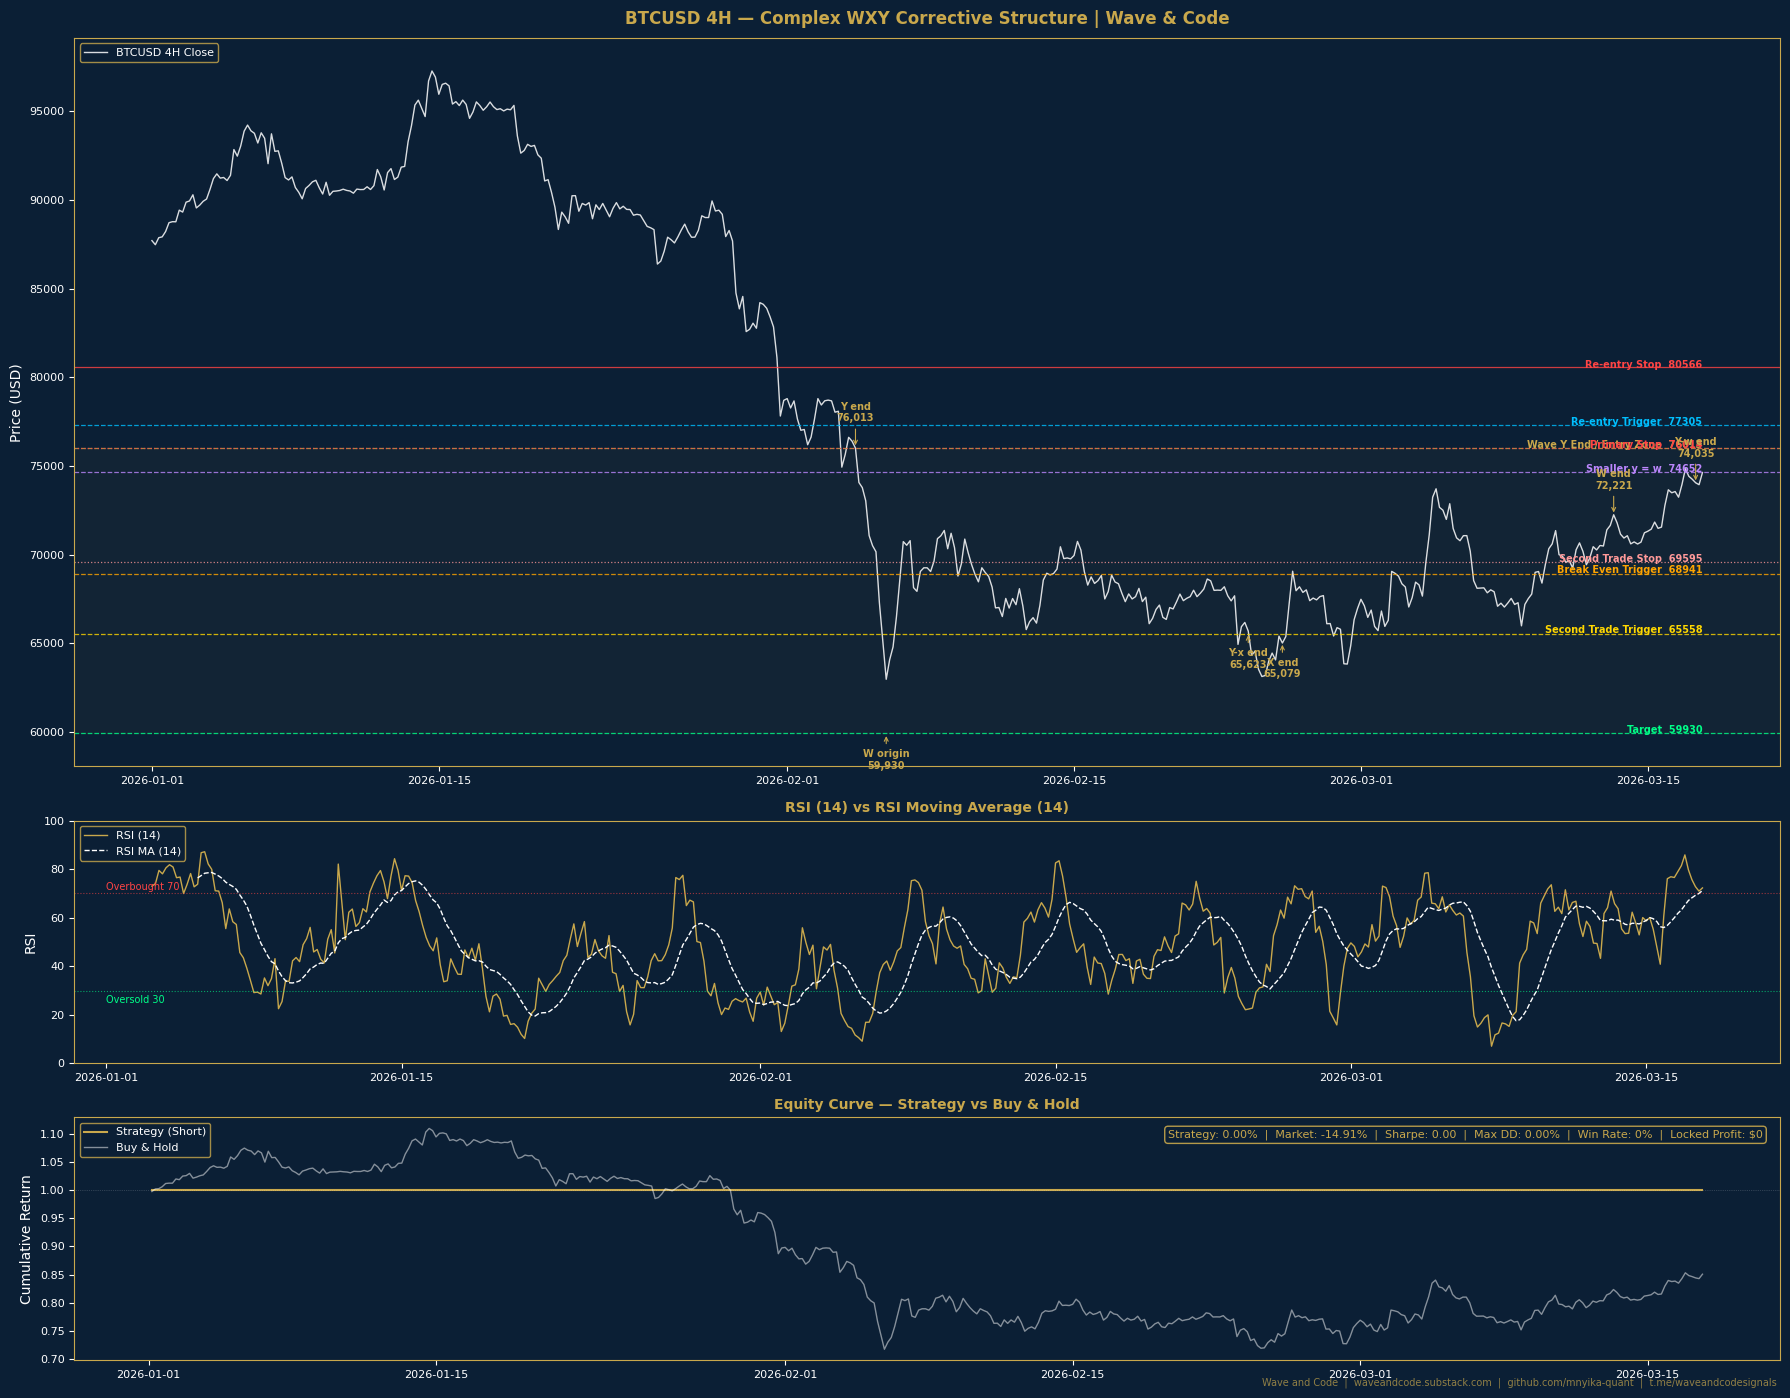

Chart saved as btcusd_complex_wxy_backtest.png


In [149]:
# ============================================================
# CHART — THREE PANELS — BTCUSD COMPLEX WXY
# ============================================================

NAVY   = '#0B1F35'
GOLD_C = '#C9A84C'
WHITE  = '#FFFFFF'
GREEN  = '#00FF88'
RED    = '#FF4444'
ORANGE = '#FFA500'
PURPLE = '#BB86FC'

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(18, 14),
    gridspec_kw={'height_ratios': [3, 1, 1]}
)
fig.patch.set_facecolor(NAVY)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(NAVY)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.title.set_color(GOLD_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GOLD_C)

# ---- PANEL 1 — PRICE ----
ax1.set_title(
    'BTCUSD 4H — Complex WXY Corrective Structure | Wave & Code',
    fontsize=12, fontweight='bold', pad=10
)
ax1.plot(btc.index, btc['Close'],
         color=WHITE, linewidth=1, alpha=0.85,
         label='BTCUSD 4H Close')

# Key levels
levels = [
    (Y_Y_END,              GOLD_C,    '--', f'Wave Y End / Entry Zone  {Y_Y_END}',         10),
    (PRIMARY_STOP,         RED,       ':',  f'Primary Stop  {PRIMARY_STOP}',                10),
    (SMALLER_Y_EQ_W,       PURPLE,    '--', f'Smaller y = w  {SMALLER_Y_EQ_W}',             10),
    (BREAK_EVEN_TRIGGER,   ORANGE,    '--', f'Break Even Trigger  {BREAK_EVEN_TRIGGER}',    10),
    (SECOND_TRADE_TRIGGER, '#FFD700', '--', f'Second Trade Trigger  {SECOND_TRADE_TRIGGER}',10),
    (SECOND_TRADE_STOP,    '#FF9999', ':',  f'Second Trade Stop  {SECOND_TRADE_STOP}',      10),
    (REENTRY_TRIGGER,      '#00BFFF', '--', f'Re-entry Trigger  {REENTRY_TRIGGER}',         10),
    (REENTRY_STOP,         RED,       '-',  f'Re-entry Stop  {REENTRY_STOP}',              -20),
    (TARGET,               GREEN,     '--', f'Target  {TARGET}',                            10),
]
for level, color, style, label, offset in levels:
    ax1.axhline(y=level, color=color, linestyle=style,
                linewidth=0.9, alpha=0.8)
    ax1.text(
        btc.index[-1], level + offset, label,
        color=color, fontsize=7, ha='right', fontweight='bold'
    )

# Wave annotations
wave_points = [
    ('W origin\n59,930',   W_ORIGIN,   'below'),
    ('W end\n72,221',      W_C_END,    'above'),
    ('X end\n65,079',      X_E_END,    'below'),
    ('Y-w end\n74,035',    Y_W_END,    'above'),
    ('Y-x end\n65,623',    Y_X_END,    'below'),
    ('Y end\n76,013',      Y_Y_END,    'above'),
]
for label, level, position in wave_points:
    closest_idx = (btc['Close'] - level).abs().idxmin()
    offset      = 1500 if position == 'above' else -2000
    ax1.annotate(
        label,
        xy=(closest_idx, level),
        xytext=(closest_idx, level + offset),
        color=GOLD_C, fontsize=7, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=GOLD_C, lw=0.8)
    )

# Mark trade events
if len(trade_df) > 0:
    for _, row in trade_df.iterrows():
        event_date  = pd.Timestamp(row['Date'])
        event_price = row['Price']
        if 'ENTRY' in row['Event']:
            ax1.scatter(event_date, event_price,
                       color=GREEN, s=150, zorder=6, marker='^')
        elif 'EXIT' in row['Event'] or 'STOP' in row['Event']:
            ax1.scatter(event_date, event_price,
                       color=RED, s=150, zorder=6, marker='v')
        elif 'BREAK EVEN' in row['Event']:
            ax1.scatter(event_date, event_price,
                       color=ORANGE, s=100, zorder=6, marker='D')

ax1.axhspan(TARGET, Y_Y_END, alpha=0.04, color=GOLD_C)
ax1.set_ylabel('Price (USD)', fontsize=10)
ax1.legend(loc='upper left',
           facecolor=NAVY, edgecolor=GOLD_C,
           labelcolor=WHITE, fontsize=8)

# ---- PANEL 2 — RSI ----
ax2.set_title('RSI (14) vs RSI Moving Average (14)',
              fontsize=10, fontweight='bold')
ax2.plot(btc.index, btc['RSI'],
         color=GOLD_C, linewidth=1, label='RSI (14)')
ax2.plot(btc.index, btc['RSI_MA'],
         color=WHITE, linewidth=1, linestyle='--', label='RSI MA (14)')
ax2.axhline(y=70, color=RED,   linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axhline(y=30, color=GREEN, linestyle=':', linewidth=0.8, alpha=0.6)
ax2.text(btc.index[0], 71.5, 'Overbought 70', color=RED,   fontsize=7)
ax2.text(btc.index[0], 25.0, 'Oversold 30',   color=GREEN, fontsize=7)
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_ylim(0, 100)

entry_signals = btc[
    btc['RSI_cross_below'] &
    (btc['Close'] <= Y_Y_END) &
    (btc.index >= ENTRY_DATE)
]
if len(entry_signals) > 0:
    ax2.scatter(entry_signals.index, entry_signals['RSI'],
               color=RED, s=60, zorder=5, label='Short Entry Signal')
ax2.legend(loc='upper left',
           facecolor=NAVY, edgecolor=GOLD_C,
           labelcolor=WHITE, fontsize=8)

# ---- PANEL 3 — EQUITY CURVE ----
ax3.set_title('Equity Curve — Strategy vs Buy & Hold',
              fontsize=10, fontweight='bold')
ax3.plot(btc.index, btc['cumulative_strategy'],
         color=GOLD_C, linewidth=1.5, label='Strategy (Short)')
ax3.plot(btc.index, btc['cumulative_market'],
         color=WHITE, linewidth=1.0, alpha=0.5, label='Buy & Hold')
ax3.axhline(y=1, color=WHITE, linestyle=':', linewidth=0.5, alpha=0.3)
ax3.set_ylabel('Cumulative Return', fontsize=10)

perf_text = (
    f'Strategy: {strategy_total:.2f}%  |  '
    f'Market: {market_total:.2f}%  |  '
    f'Sharpe: {sharpe_strategy:.2f}  |  '
    f'Max DD: {max_drawdown*100:.2f}%  |  '
    f'Win Rate: {win_rate*100:.0f}%  |  '
    f'Locked Profit: ${locked_in_profit:,.0f}'
)
ax3.text(
    0.99, 0.95, perf_text,
    transform=ax3.transAxes,
    ha='right', va='top', color=GOLD_C, fontsize=8,
    bbox=dict(boxstyle='round', facecolor=NAVY,
              edgecolor=GOLD_C, alpha=0.9)
)
ax3.legend(loc='upper left',
           facecolor=NAVY, edgecolor=GOLD_C,
           labelcolor=WHITE, fontsize=8)

fig.text(
    0.99, 0.005,
    'Wave and Code  |  waveandcode.substack.com  |  '
    'github.com/mnyika-quant  |  t.me/waveandcodesignals',
    ha='right', va='bottom', color=GOLD_C, fontsize=7, alpha=0.7
)

plt.tight_layout()
plt.savefig('btcusd_complex_wxy_backtest.png',
            dpi=150, bbox_inches='tight', facecolor=NAVY)
plt.show()
print('Chart saved as btcusd_complex_wxy_backtest.png')


In [150]:
print("""
BTCUSD COMPLEX WXY — INTERPRETATION
=====================================

WAVE STRUCTURE:
A complex WXY corrective structure has completed on the
4 hour chart. Wave W unfolded as an ABC structure from
59,930 to 72,221. Wave X developed as a triangle ABCDE
from 72,221 to 65,079. Wave Y subdivided as a WXY
structure from 65,079 to 76,013.

PRIMARY ENTRY RATIONALE:
Within the larger Wave Y the smaller y achieved equality
with the smaller w at 74,652 — a primary Fibonacci
relationship marking the minimum expectation for the
corrective advance. The RSI crossing below its MA
confirms momentum has shifted to the downside.

RE-ENTRY FRAMEWORK:
If the primary trade is stopped out at 76,014 the
re-entry is armed at 77,305 where the larger Y achieves
equality with the larger W. A fresh RSI cross below MA
at that level provides the momentum confirmation for
re-entry with a stop at 80,566.

ATR POSITION SIZING:
Position size is calculated dynamically so that one ATR
of adverse movement equals exactly $100,000 risk. This
ensures consistent dollar risk regardless of volatility.

TARGET:
The full target at 59,930 represents the origin of the
entire WXY corrective sequence — the level at which the
larger degree trend is expected to resume its primary
direction.

EMAIL ALERTS:
Automated email alerts are sent to munyacountry@gmail.com
at every key level — entry, break even, second trade,
target approach, and exit events.

Wave and Code | waveandcode.substack.com
github.com/mnyika-quant | t.me/waveandcodesignals
""")



BTCUSD COMPLEX WXY — INTERPRETATION

WAVE STRUCTURE:
A complex WXY corrective structure has completed on the
4 hour chart. Wave W unfolded as an ABC structure from
59,930 to 72,221. Wave X developed as a triangle ABCDE
from 72,221 to 65,079. Wave Y subdivided as a WXY
structure from 65,079 to 76,013.

PRIMARY ENTRY RATIONALE:
Within the larger Wave Y the smaller y achieved equality
with the smaller w at 74,652 — a primary Fibonacci
relationship marking the minimum expectation for the
corrective advance. The RSI crossing below its MA
confirms momentum has shifted to the downside.

RE-ENTRY FRAMEWORK:
If the primary trade is stopped out at 76,014 the
re-entry is armed at 77,305 where the larger Y achieves
equality with the larger W. A fresh RSI cross below MA
at that level provides the momentum confirmation for
re-entry with a stop at 80,566.

ATR POSITION SIZING:
Position size is calculated dynamically so that one ATR
of adverse movement equals exactly $100,000 risk. This
ensures consi

In [151]:
print('=== DOLLAR BASED PERFORMANCE — WHAT ACTUALLY MATTERS ===')
print()
print(f'Starting Capital:        ${CAPITAL:>14,.2f}')
print(f'Locked In Profit:        ${locked_in_profit:>14,.2f}')
print(f'Final Equity:            ${CAPITAL + locked_in_profit:>14,.2f}')
print(f'Return on Capital:       {(locked_in_profit/CAPITAL)*100:>13.2f}%')
print()
print('=== TRADE BY TRADE BREAKDOWN ===')
print()
for _, row in trade_df.iterrows():
    print(f"{row['Event']:<45} "
          f"Price: {row['Price']:>10.2f}  "
          f"Lots: {row['Lots']:>8.4f}  "
          f"Equity: ${row['Total Equity']:>14,.2f}")


=== DOLLAR BASED PERFORMANCE — WHAT ACTUALLY MATTERS ===

Starting Capital:        $  1,000,000.00
Locked In Profit:        $          0.00
Final Equity:            $  1,000,000.00
Return on Capital:                0.00%

=== TRADE BY TRADE BREAKDOWN ===



In [152]:
# ============================================================
# DIAGNOSTIC — Check conditions on 17 March 2026
# ============================================================

# Filter bars from 17 March 2026
march_17 = btc[btc.index >= pd.Timestamp('2026-03-17', tz='UTC')]

print('=== BARS FROM 17 MARCH 2026 ===')
print()
print(march_17[['Open','High','Low','Close','RSI','RSI_MA',
                'RSI_cross_below']].to_string())
print()
print('=== ENTRY CONDITION CHECK ===')
for i, (idx, row) in enumerate(march_17.iterrows()):
    print(f'Bar {i+1} — {idx}')
    print(f'  Close:           {row["Close"]:.2f}')
    print(f'  RSI:             {row["RSI"]:.2f}')
    print(f'  RSI MA:          {row["RSI_MA"]:.2f}')
    print(f'  RSI cross below: {row["RSI_cross_below"]}')
    print(f'  Below Y_Y_END:   {row["Close"] <= Y_Y_END} ({Y_Y_END})')
    print(f'  Above X_E_END:   {row["Close"] >= X_E_END} ({X_E_END})')
    print(f'  Date valid:      {idx >= ENTRY_DATE}')
    print()

=== BARS FROM 17 MARCH 2026 ===

Price                              Open          High           Low         Close        RSI     RSI_MA  RSI_cross_below
Datetime                                                                                                                
2026-03-17 00:00:00+00:00  74871.296875  75954.968750  74309.460938  74423.710938  79.704102  67.065931            False
2026-03-17 04:00:00+00:00  74545.046875  74652.742188  73839.921875  74257.460938  75.647130  68.180321            False
2026-03-17 08:00:00+00:00  74254.460938  74425.851562  73614.750000  74057.859375  72.766430  69.187683            False
2026-03-17 12:00:00+00:00  74036.242188  74816.500000  73459.250000  73949.937500  70.928724  69.966104            False
2026-03-17 16:00:00+00:00  73943.617188  74657.601562  73905.640625  74635.625000  72.245872  71.183363            False

=== ENTRY CONDITION CHECK ===
Bar 1 — 2026-03-17 00:00:00+00:00
  Close:           74423.71
  RSI:             79.70
  

In [153]:
# ============================================================
# CURRENT TRADE STATUS — LIVE POSITION
# ============================================================

current_price = btc['Close'].iloc[-1]
current_time  = btc.index[-1]

print('=== LIVE POSITION STATUS ===')
print()
print(f'Last Bar Time:        {current_time}')
print(f'Current Price:        {current_price:>12.2f}')
print()

if primary_active and entry_price_primary is not None:
    # Trade is active — show full position details
    stop_distance     = abs(entry_price_primary - PRIMARY_STOP)
    unrealised_profit = (entry_price_primary - current_price) * lots_primary

    print(f'Status:               TRADE ACTIVE')
    print(f'Entry Price:          {entry_price_primary:>12.2f}')
    print(f'Lots:                 {lots_primary:>12.4f}')
    print(f'Stop Loss:            {PRIMARY_STOP:>12}')
    print(f'Stop Distance:        {stop_distance:>12.2f} points')
    print(f'Risk:                 ${RISK_PER_TRADE:>12,.2f} (2%)')
    print()
    print(f'Points in favour:     {entry_price_primary - current_price:>12.2f}')
    print(f'Unrealised Profit:    ${unrealised_profit:>12,.2f}')
    print(f'Current Equity:       ${CAPITAL + unrealised_profit:>12,.2f}')
    print(f'Unrealised Return:    {(unrealised_profit/CAPITAL)*100:>11.2f}%')
    print()
    points_to_target = entry_price_primary - TARGET
    profit_at_target = points_to_target * lots_primary
    print('=== POTENTIAL AT TARGET ===')
    print(f'  Points to target:     {points_to_target:>10.2f}')
    print(f'  Profit at target:     ${profit_at_target:>12,.2f}')
    print(f'  Return at target:     {(profit_at_target/CAPITAL)*100:>11.2f}%')
    print(f'  Final equity:         ${CAPITAL + profit_at_target:>12,.2f}')

elif primary_stopped and entry_price_primary is None:
    # Primary was stopped out — re-entry armed
    print(f'Status:               PRIMARY STOPPED OUT')
    print(f'Re-entry armed at:    {REENTRY_TRIGGER}')
    print(f'Re-entry stop:        {REENTRY_STOP}')
    print(f'Locked profit so far: ${locked_in_profit:>12,.2f}')
    print(f'Current equity:       ${CAPITAL + locked_in_profit:>12,.2f}')

elif reentry_active and entry_price_reentry is not None:
    # Re-entry trade is active
    stop_distance     = abs(entry_price_reentry - REENTRY_STOP)
    unrealised_profit = (entry_price_reentry - current_price) * lots_reentry

    print(f'Status:               RE-ENTRY TRADE ACTIVE')
    print(f'Entry Price:          {entry_price_reentry:>12.2f}')
    print(f'Lots:                 {lots_reentry:>12.4f}')
    print(f'Stop Loss:            {REENTRY_STOP:>12}')
    print(f'Stop Distance:        {stop_distance:>12.2f} points')
    print(f'Risk:                 ${RISK_PER_TRADE:>12,.2f} (2%)')
    print()
    print(f'Points in favour:     {entry_price_reentry - current_price:>12.2f}')
    print(f'Unrealised Profit:    ${unrealised_profit:>12,.2f}')
    print(f'Current Equity:       ${CAPITAL + unrealised_profit:>12,.2f}')

else:
    # No trade active — waiting for entry signal
    print(f'Status:               WAITING FOR ENTRY SIGNAL')
    print()
    print(f'Entry conditions:')
    print(f'  Price below Y_Y_END {Y_Y_END}:   {current_price <= Y_Y_END}')
    print(f'  Price above X_E_END {X_E_END}:   {current_price >= X_E_END}')
    print()
    print(f'RSI Status:')
    print(f'  Current RSI:          {btc["RSI"].iloc[-1]:.2f}')
    print(f'  Current RSI MA:       {btc["RSI_MA"].iloc[-1]:.2f}')
    print(f'  Gap to crossover:     {btc["RSI"].iloc[-1] - btc["RSI_MA"].iloc[-1]:.2f} points')
    print(f'  RSI cross below:      {btc["RSI_cross_below"].iloc[-1]}')
    print()
    if btc["RSI"].iloc[-1] > btc["RSI_MA"].iloc[-1]:
        gap = btc["RSI"].iloc[-1] - btc["RSI_MA"].iloc[-1]
        print(f'  RSI is {gap:.2f} points ABOVE MA — entry not yet triggered')
        print(f'  Entry fires when RSI crosses BELOW MA')
    else:
        print(f'  RSI is BELOW MA — checking other conditions')
    print()
    print(f'Locked profit so far: ${locked_in_profit:>12,.2f}')
    print(f'Current equity:       ${CAPITAL + locked_in_profit:>12,.2f}')

print()
print('=== KEY LEVELS TO WATCH ===')
print(f'  Stop loss:            {PRIMARY_STOP:>10}')
print(f'  Break even trigger:   {BREAK_EVEN_TRIGGER:>10}')
print(f'  Second trade trigger: {SECOND_TRADE_TRIGGER:>10}')
print(f'  Re-entry trigger:     {REENTRY_TRIGGER:>10}')
print(f'  Full invalidation:    {REENTRY_STOP:>10}')
print(f'  Full target:          {TARGET:>10}')



=== LIVE POSITION STATUS ===

Last Bar Time:        2026-03-17 16:00:00+00:00
Current Price:            74635.62

Status:               WAITING FOR ENTRY SIGNAL

Entry conditions:
  Price below Y_Y_END 76013:   True
  Price above X_E_END 65079:   True

RSI Status:
  Current RSI:          72.25
  Current RSI MA:       71.18
  Gap to crossover:     1.06 points
  RSI cross below:      False

  RSI is 1.06 points ABOVE MA — entry not yet triggered
  Entry fires when RSI crosses BELOW MA

Locked profit so far: $        0.00
Current equity:       $1,000,000.00

=== KEY LEVELS TO WATCH ===
  Stop loss:                 76014
  Break even trigger:        68941
  Second trade trigger:      65558
  Re-entry trigger:          77305
  Full invalidation:         80566
  Full target:               59930


In [154]:
# ============================================================
# DIAGNOSTIC — Why did no entry fire
# ============================================================

print('=== STATE VARIABLES AFTER CELL 6 ===')
print(f'primary_active:       {primary_active}')
print(f'entry_price_primary:  {entry_price_primary}')
print(f'lots_primary:         {lots_primary}')
print()

# Check bars from entry date
march_17 = btc[btc.index >= ENTRY_DATE]
print(f'Bars from entry date: {len(march_17)}')
print()

if len(march_17) > 0:
    print('=== BAR BY BAR CHECK ===')
    for idx, row in march_17.iterrows():
        print(f'Time:            {idx}')
        print(f'Close:           {row["Close"]:.2f}')
        print(f'RSI:             {row["RSI"]:.2f}')
        print(f'RSI MA:          {row["RSI_MA"]:.2f}')
        print(f'RSI cross below: {row["RSI_cross_below"]}')
        print(f'Below Y_Y_END:   {row["Close"] <= Y_Y_END}')
        print(f'Above X_E_END:   {row["Close"] >= X_E_END}')
        print()
else:
    print('NO BARS FOUND FROM ENTRY DATE')
    print(f'Last bar in dataset: {btc.index[-1]}')
    print(f'ENTRY_DATE:          {ENTRY_DATE}')


=== STATE VARIABLES AFTER CELL 6 ===
primary_active:       False
entry_price_primary:  None
lots_primary:         0

Bars from entry date: 5

=== BAR BY BAR CHECK ===
Time:            2026-03-17 00:00:00+00:00
Close:           74423.71
RSI:             79.70
RSI MA:          67.07
RSI cross below: False
Below Y_Y_END:   True
Above X_E_END:   True

Time:            2026-03-17 04:00:00+00:00
Close:           74257.46
RSI:             75.65
RSI MA:          68.18
RSI cross below: False
Below Y_Y_END:   True
Above X_E_END:   True

Time:            2026-03-17 08:00:00+00:00
Close:           74057.86
RSI:             72.77
RSI MA:          69.19
RSI cross below: False
Below Y_Y_END:   True
Above X_E_END:   True

Time:            2026-03-17 12:00:00+00:00
Close:           73949.94
RSI:             70.93
RSI MA:          69.97
RSI cross below: False
Below Y_Y_END:   True
Above X_E_END:   True

Time:            2026-03-17 16:00:00+00:00
Close:           74635.62
RSI:             72.25
RSI MA:  